In [16]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [17]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_A,B.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [18]:
# 데이터를 읽어온다.
train_df = pd.read_csv('model3_train_AB.csv')
test_df = pd.read_csv('model3_test_AB.csv')

display(train_df)
display(test_df)

,방문횟수_앱_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,방문일수_PC_R6M,방문횟수_PC_R6M,이용후경과월_할부_무이자,이용개월수_할부_무이자_R12M,카드이용한도금액_B2M,CA한도금액,이용건수_할부_무이자_R3M,이용건수_할부_R3M,이용금액_할부_무이자_R6M,거주시도명,연령,Life_Stage,캠페인접촉건수_R12M,캠페인접촉일수_R12M,할인건수_R3M
0,1회 이상,10회 이상,10회 이상,1회 이상,1회 이상,0,9,224182,57536,6,7,40359,경기,40대,자녀성장(1),5회 이상,5일 이상,1회 이상
1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,0,9,214877,53971,5,5,29199,부산,50대,자녀성장(2),1회 이상,1일 이상,1회 이상
2,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1,9,193306,53533,5,5,41888,경기,40대,자녀성장(2),1회 이상,1일 이상,1회 이상
3,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1,4,208477,57970,1,1,4535,경기,40대,자녀성장(1),5회 이상,5일 이상,1회 이상
4,1회 이상,1회 이상,1회 이상,20회 이상,30회 이상,1,7,211000,60800,4,4,40012,서울,30대,자녀성장(1),1회 이상,1일 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,0,9,211045,0,6,6,42292,경기,40대,자녀성장(2),1회 이상,1일 이상,1회 이상
1112,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,6,3,175851,52255,0,0,0,서울,50대,자녀성장(2),1회 이상,1일 이상,10회 이상
1113,1회 이상,10회 이상,30회 이상,1회 이상,1회 이상,1,9,63486,19216,6,6,38365,서울,50대,자녀독립기,1회 이상,1일 이상,1회 이상
1114,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,6,3,211372,59353,0,0,0,서울,40대,자녀성장(1),10회 이상,10일 이상,1회 이상


,ID,기준년월,이용후경과월_할부_무이자,이용개월수_할부_무이자_R12M,카드이용한도금액_B2M,CA한도금액,이용건수_할부_무이자_R3M,이용건수_할부_R3M,이용금액_할부_무이자_R6M,방문횟수_앱_R6M,거주시도명,연령,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,TEST_00000,201807,12,0,50006,18131,0,0,0,1회 이상,경기,40대,자녀성장(1),1회 이상,1회 이상,1회 이상,1일 이상,1회 이상,1회 이상,1회 이상
1,TEST_00001,201807,0,9,50003,16819,6,7,16654,1회 이상,인천,60대,자녀독립기,1회 이상,5회 이상,1회 이상,5일 이상,1회 이상,1회 이상,1회 이상
2,TEST_00002,201807,3,5,100056,30505,0,2,13260,1회 이상,경기,40대,자녀성장(1),1회 이상,10회 이상,1회 이상,10일 이상,1회 이상,1회 이상,1회 이상
3,TEST_00003,201807,2,1,19693,6402,1,2,-685,1회 이상,인천,40대,자녀성장(1),1회 이상,15회 이상,1회 이상,15일 이상,1회 이상,1회 이상,1회 이상
4,TEST_00004,201807,0,6,3924,0,3,4,9332,1회 이상,경기,40대,자녀성장(1),1회 이상,1회 이상,1회 이상,1일 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,TEST_99995,201812,12,0,0,0,0,0,0,1회 이상,경기,60대,노년생활,1회 이상,1회 이상,1회 이상,1일 이상,1회 이상,1회 이상,1회 이상
599996,TEST_99996,201812,12,0,49990,17876,0,0,0,10회 이상,서울,30대,자녀출산기,1회 이상,1회 이상,1회 이상,1일 이상,1회 이상,1회 이상,1회 이상
599997,TEST_99997,201812,12,0,30004,13332,0,0,0,1회 이상,경남,30대,자녀성장(1),1회 이상,1회 이상,1회 이상,1일 이상,1회 이상,1회 이상,1회 이상
599998,TEST_99998,201812,2,3,37139,17362,0,0,0,40회 이상,경남,30대,가족구축기,1회 이상,5회 이상,1회 이상,5일 이상,1회 이상,1회 이상,1회 이상


In [19]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,방문횟수_앱_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,방문일수_PC_R6M,방문횟수_PC_R6M,이용후경과월_할부_무이자,이용개월수_할부_무이자_R12M,카드이용한도금액_B2M,CA한도금액,이용건수_할부_무이자_R3M,이용건수_할부_R3M,이용금액_할부_무이자_R6M,거주시도명,연령,Life_Stage,캠페인접촉건수_R12M,캠페인접촉일수_R12M,할인건수_R3M,ID,기준년월
0,1회 이상,10회 이상,10회 이상,1회 이상,1회 이상,0,9,224182,57536,6,7,40359,경기,40대,자녀성장(1),5회 이상,5일 이상,1회 이상,NaN,NaN
1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,0,9,214877,53971,5,5,29199,부산,50대,자녀성장(2),1회 이상,1일 이상,1회 이상,NaN,NaN
2,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1,9,193306,53533,5,5,41888,경기,40대,자녀성장(2),1회 이상,1일 이상,1회 이상,NaN,NaN
3,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1,4,208477,57970,1,1,4535,경기,40대,자녀성장(1),5회 이상,5일 이상,1회 이상,NaN,NaN
4,1회 이상,1회 이상,1회 이상,20회 이상,30회 이상,1,7,211000,60800,4,4,40012,서울,30대,자녀성장(1),1회 이상,1일 이상,1회 이상,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601111,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,12,0,0,0,0,0,0,경기,60대,노년생활,1회 이상,1일 이상,1회 이상,TEST_99995,201812.0
601112,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,12,0,49990,17876,0,0,0,서울,30대,자녀출산기,1회 이상,1일 이상,1회 이상,TEST_99996,201812.0
601113,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,12,0,30004,13332,0,0,0,경남,30대,자녀성장(1),1회 이상,1일 이상,1회 이상,TEST_99997,201812.0
601114,40회 이상,1회 이상,1회 이상,1회 이상,1회 이상,2,3,37139,17362,0,0,0,경남,30대,가족구축기,5회 이상,5일 이상,1회 이상,TEST_99998,201812.0


In [20]:
all_df=all_df.drop(columns=['ID','기준년월'])

In [21]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601116 entries, 0 to 601115
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   방문횟수_앱_R6M         601116 non-null  object
 1   인입횟수_ARS_R6M       601116 non-null  object
 2   이용메뉴건수_ARS_R6M     601116 non-null  object
 3   방문일수_PC_R6M        601116 non-null  object
 4   방문횟수_PC_R6M        601116 non-null  object
 5   이용후경과월_할부_무이자      601116 non-null  int64 
 6   이용개월수_할부_무이자_R12M  601116 non-null  int64 
 7   카드이용한도금액_B2M       601116 non-null  int64 
 8   CA한도금액             601116 non-null  int64 
 9   이용건수_할부_무이자_R3M    601116 non-null  int64 
 10  이용건수_할부_R3M        601116 non-null  int64 
 11  이용금액_할부_무이자_R6M    601116 non-null  int64 
 12  거주시도명              601116 non-null  object
 13  연령                 601116 non-null  object
 14  Life_Stage         601116 non-null  object
 15  캠페인접촉건수_R12M       601116 non-null  object
 16  캠페인접촉일수_R12M       6

In [22]:
# LabelEncoder 학습
Encoder2 = LabelEncoder()
Encoder3 = LabelEncoder()
Encoder4 = LabelEncoder()
Encoder5 = LabelEncoder()
Encoder6 = LabelEncoder()
Encoder7 = LabelEncoder()
Encoder8 = LabelEncoder()
Encoder9 = LabelEncoder()
Encoder10 = LabelEncoder()
Encoder11 = LabelEncoder()
Encoder12 = LabelEncoder()

Encoder2.fit(all_df['방문횟수_앱_R6M'])
Encoder3.fit(all_df['인입횟수_ARS_R6M'])
Encoder4.fit(all_df['이용메뉴건수_ARS_R6M'])
Encoder5.fit(all_df['방문일수_PC_R6M'])
Encoder6.fit(all_df['방문횟수_PC_R6M'])
Encoder7.fit(all_df['거주시도명'])
Encoder8.fit(all_df['연령'])
Encoder9.fit(all_df['Life_Stage'])
Encoder10.fit(all_df['할인건수_R3M'])
Encoder11.fit(all_df['캠페인접촉일수_R12M'])
Encoder12.fit(all_df['캠페인접촉건수_R12M'])

LabelEncoder()

In [23]:
all_df['방문횟수_앱_R6M'] = Encoder2.transform(all_df['방문횟수_앱_R6M'])
all_df['인입횟수_ARS_R6M'] = Encoder3.transform(all_df['인입횟수_ARS_R6M'])
all_df['이용메뉴건수_ARS_R6M'] = Encoder4.transform(all_df['이용메뉴건수_ARS_R6M'])
all_df['방문일수_PC_R6M'] = Encoder5.transform(all_df['방문일수_PC_R6M'])
all_df['방문횟수_PC_R6M'] = Encoder6.transform(all_df['방문횟수_PC_R6M'])
all_df['거주시도명'] = Encoder7.transform(all_df['거주시도명'])
all_df['연령'] = Encoder8.transform(all_df['연령'])
all_df['Life_Stage'] = Encoder9.transform(all_df['Life_Stage'])
all_df['할인건수_R3M'] = Encoder10.transform(all_df['할인건수_R3M'])
all_df['캠페인접촉일수_R12M'] = Encoder11.transform(all_df['캠페인접촉일수_R12M'])
all_df['캠페인접촉건수_R12M'] = Encoder12.transform(all_df['캠페인접촉건수_R12M'])

In [24]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(all_df)

,copy,True
,with_mean,True
,with_std,True


In [25]:
train_df['방문횟수_앱_R6M'] = Encoder2.transform(train_df['방문횟수_앱_R6M'])
train_df['인입횟수_ARS_R6M'] = Encoder3.transform(train_df['인입횟수_ARS_R6M'])
train_df['이용메뉴건수_ARS_R6M'] = Encoder4.transform(train_df['이용메뉴건수_ARS_R6M'])
train_df['방문일수_PC_R6M'] = Encoder5.transform(train_df['방문일수_PC_R6M'])
train_df['방문횟수_PC_R6M'] = Encoder6.transform(train_df['방문횟수_PC_R6M'])
train_df['거주시도명'] = Encoder7.transform(train_df['거주시도명'])
train_df['연령'] = Encoder8.transform(train_df['연령'])
train_df['Life_Stage'] = Encoder9.transform(train_df['Life_Stage'])
train_df['할인건수_R3M'] = Encoder10.transform(train_df['할인건수_R3M'])
train_df['캠페인접촉일수_R12M'] = Encoder11.transform(train_df['캠페인접촉일수_R12M'])
train_df['캠페인접촉건수_R12M'] = Encoder12.transform(train_df['캠페인접촉건수_R12M'])

In [26]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [27]:
tg_df = pd.concat([
    target1['Segment'],
    target2['Segment'],
    target3['Segment'],
    target4['Segment'],
    target5['Segment'],
    target6['Segment']
])

tg_df = tg_df.reset_index(drop=True).to_frame(name='Segment')
tg_df = tg_df[tg_df['Segment'].isin(['A', 'B'])].reset_index(drop=True)
tg_df

,Segment
0,A
1,A
2,A
3,A
4,A
...,...
1111,A
1112,A
1113,B
1114,A


In [28]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
tg_df['Segment'] = le.fit_transform(tg_df['Segment'])

In [29]:
# 입력과 결과로 나눈다.
X = train_df
y = tg_df

In [30]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-0.2221174 , -5.58680782, -4.3746411 , ...,  2.11362689,
         1.97436211,  0.15252693],
       [-0.2221174 ,  0.17899309,  0.08509705, ..., -0.25974231,
        -0.16059332,  0.15252693],
       [-0.2221174 ,  0.17899309,  0.08509705, ..., -0.25974231,
        -0.16059332,  0.15252693],
       ...,
       [-0.2221174 , -5.58680782,  9.00457335, ..., -0.25974231,
        -0.16059332,  0.15252693],
       [-0.2221174 ,  0.17899309,  0.08509705, ..., -1.84198844,
        -2.29554875,  0.15252693],
       [-0.2221174 ,  0.17899309,  0.08509705, ..., -0.25974231,
        -0.16059332,  0.15252693]])

In [31]:
scaler_columns = X.columns.tolist()
scaler_columns

['방문횟수_앱_R6M',
 '인입횟수_ARS_R6M',
 '이용메뉴건수_ARS_R6M',
 '방문일수_PC_R6M',
 '방문횟수_PC_R6M',
 '이용후경과월_할부_무이자',
 '이용개월수_할부_무이자_R12M',
 '카드이용한도금액_B2M',
 'CA한도금액',
 '이용건수_할부_무이자_R3M',
 '이용건수_할부_R3M',
 '이용금액_할부_무이자_R6M',
 '거주시도명',
 '연령',
 'Life_Stage',
 '캠페인접촉건수_R12M',
 '캠페인접촉일수_R12M',
 '할인건수_R3M']

In [32]:
train_X = X2
train_y = y

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [33]:
# KNN
knn_basic_model = KNeighborsClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(knn_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9506917631917633


In [34]:
# LogisticRegression
lr_basic_model = LogisticRegression()
# 교차 검증을 수행한다
r1 = cross_val_score(lr_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9336550836550837


In [35]:
# SVC
svc_basic_model = SVC(probability=True)
# 교차 검증을 수행한다
r1 = cross_val_score(svc_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9363577863577864


In [36]:
# DecisionTree
tree_basic_model = DecisionTreeClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(tree_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9524533462033464


In [37]:
# RandomForest
rf_basic_model = RandomForestClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(rf_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9775740025740027


In [38]:
# AdaBoost
ada_basic_model = AdaBoostClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(ada_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9228844916344917


In [39]:
# GradientBoost
gb_basic_model = GradientBoostingClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(gb_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoost Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9578507078507078


In [40]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9766891891891893


In [41]:
# XGBoost
xgboost_basic_model = XGBClassifier(verbose=-1, silent=True)
# 교차 검증을 수행한다
r1 = cross_val_score(xgboost_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9757722007722007


In [42]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_basic_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Basic")

In [43]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_basic_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Basic")

### 하이퍼 파라미터 튜닝

In [44]:
# KNN
params = {
    'n_neighbors' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = KNeighborsClassifier()
knn_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
knn_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(knn_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Tuning")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [45]:
# LogisticRegression
params = {
    'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = LogisticRegression()
lr_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lr_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(lr_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Tuning")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [46]:
# SVC
params = {
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = SVC(probability=True)
svc_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
svc_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(svc_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Tuning")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [47]:
# DecisionTree
params = {
    'max_depth' : [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = DecisionTreeClassifier()
tree_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
tree_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(tree_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Tuning")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [48]:
# RandomForest
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300]
}

temp_model = RandomForestClassifier()
rf_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
rf_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(rf_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Tuning")
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [49]:
# AdaBoost
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = AdaBoostClassifier()
ada_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
ada_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(ada_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Tuning")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.9704231016731016


In [51]:
# GradientBoosting
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = GradientBoostingClassifier()
gb_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
gb_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(gb_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoosting Tuning")

print(f'평균 f1 Score : {r1.mean()}')

KeyboardInterrupt: 

In [ ]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

In [ ]:
# XGBoost
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = XGBClassifier(verbose=-1, silent=True)
xgboost_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
xgboost_grid_clf.fit(train_X, train_y)

# 평가 결과를 담아준다.
f1_score_list.append(xgboost_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Tuning")

In [ ]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_tuning_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_tuning_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Tuning")

In [ ]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_tuning_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_tuning_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Tuning")

In [47]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
LGBM Tuning,0.981178
RandomForest Tuning,0.978467
RandomForest Basic,0.977582
LGBM Basic,0.976689
XGBoost Basic,0.975772
HardVoting Tuning,0.974895
SoftVoting Tuning,0.973995
XGBoost Tuning,0.973094
KNN Tuning,0.970415
GradientBoosting Tuning,0.969498


---

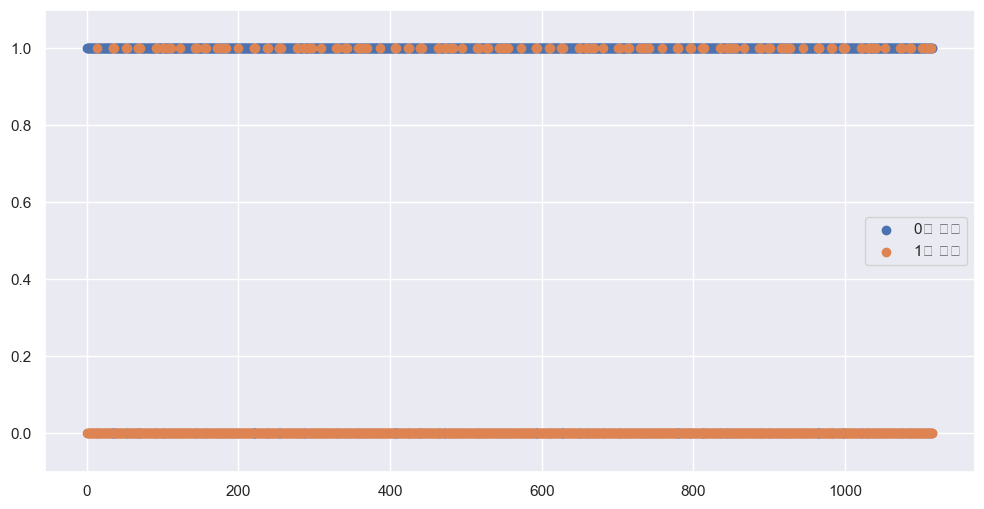

In [39]:
lgbm_grid_clf.fit(train_X, train_y)
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = lgbm_grid_clf.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

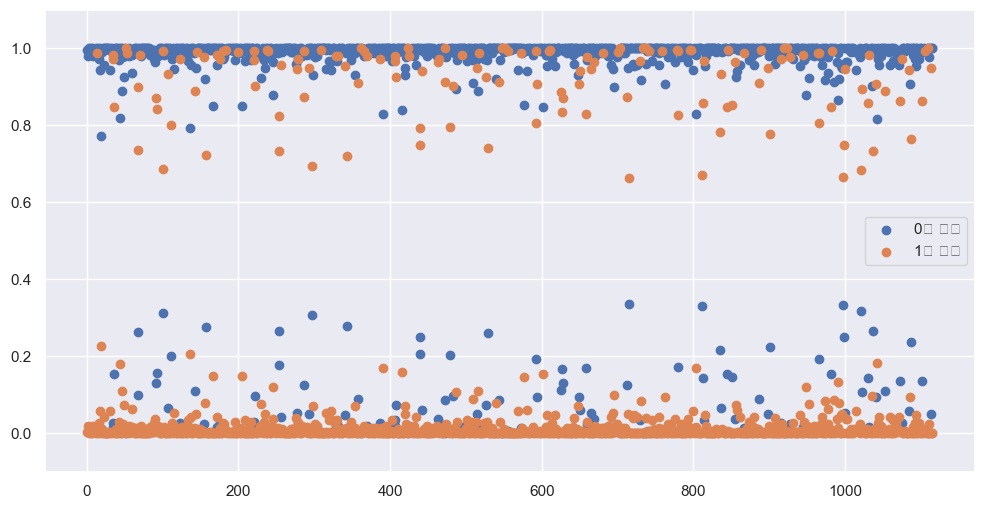

In [40]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = rf_grid_clf.best_estimator_.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

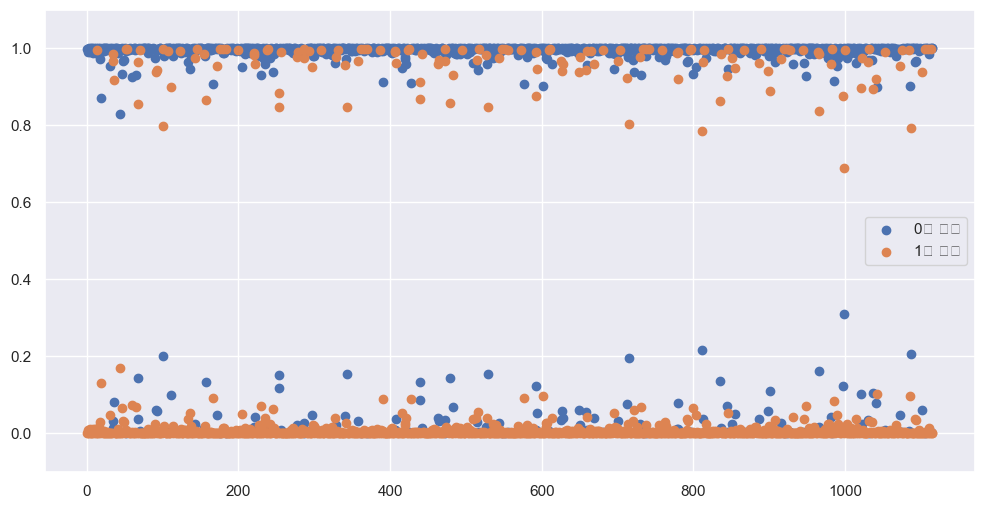

In [42]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = xgboost_grid_clf.best_estimator_.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

In [43]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = LGBMClassifier()
best_model.set_params(**lgbm_grid_clf.best_params_)
best_model.fit(train_X, train_y)
best_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [44]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(Encoder2, fp)
    pickle.dump(Encoder3, fp)
    pickle.dump(Encoder4, fp)
    pickle.dump(Encoder5, fp)
    pickle.dump(Encoder6, fp)
    pickle.dump(Encoder7, fp)
    pickle.dump(Encoder8, fp)
    pickle.dump(Encoder9, fp)
    pickle.dump(Encoder10, fp)
    pickle.dump(Encoder11, fp)
    pickle.dump(Encoder12, fp)
    pickle.dump(le, fp)

print('저장완료')

저장완료


---
### 혼동행렬